# Part 3 — Churn Prediction Model & Model Card

## Name: Chamalapalli venkatesh
## Id : iitp_aiml_2506014

## 1. Preparing the modeling data from the provided modeling snapshot

In [ ]:
# Load data and confirm the safe snapshot source
import pandas as pd
from pathlib import Path

DATA_DIR = Path('.')
snapshot = pd.read_csv(DATA_DIR / 'rfm_modeling_snapshot.csv')

print('Snapshot shape:', snapshot.shape)
print('\nProvided split counts:')
print(snapshot['split'].value_counts())
print('\nTarget distribution:')
print(snapshot['churn_next_60d'].value_counts(normalize=True).round(3))

# Confirm we are using the safe modeling snapshot
assert set(snapshot['split'].unique()) == {'train', 'validation', 'test'}
assert snapshot['snapshot_date'].nunique() == 1
print('\nSnapshot date in the modeling table:', snapshot['snapshot_date'].iloc[0])
display(snapshot.head(3))

Snapshot shape: (2400, 29)

Provided split counts:
split
train         1728
validation     336
test           336
Name: count, dtype: int64

Target distribution:
churn_next_60d
0    0.53
1    0.47
Name: proportion, dtype: float64

Snapshot date in the modeling table: 2025-09-30


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train


## 2. Separating train, validation, test data from the provided split
## Leakage check

The feature table `rfm_modeling_snapshot.csv` is documented as safe for Part 3. It contains only pre-snapshot features and the target label. The snapshot date is confirmed as `2025-09-30`, and the target window is the next 60 days.

The label column `churn_next_60d` is excluded from model input. The provided `split` column is used to keep training, validation, and test data separate.

In [ ]:
# Prepare train/validation/test data using the provided split
feature_columns = [c for c in snapshot.columns if c not in ['customer_id', 'snapshot_date', 'churn_next_60d', 'split']]
print('Feature count:', len(feature_columns))
print('Features:', feature_columns)

train_df = snapshot[snapshot['split'] == 'train'].copy()
valid_df = snapshot[snapshot['split'] == 'validation'].copy()
test_df = snapshot[snapshot['split'] == 'test'].copy()

X_train = train_df[feature_columns].copy()
y_train = train_df['churn_next_60d'].copy()
X_valid = valid_df[feature_columns].copy()
y_valid = valid_df['churn_next_60d'].copy()
X_test = test_df[feature_columns].copy()
y_test = test_df['churn_next_60d'].copy()

print('Train/Val/Test sizes:', len(X_train), len(X_valid), len(X_test))

Feature count: 25
Features: ['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago']
Train/Val/Test sizes: 1728 336 336


# Feature Encoding

Machine learning models cannot directly process categorical variables represented as text. Therefore, categorical features must be converted into numerical representations before model training.

The dataset contains three types of categorical variables:

### 1. Nominal Variables
These variables have no natural ordering and will be transformed using One-Hot Encoding.

- city_tier
- age_group
- acquisition_channel
- preferred_category

### 2. Ordinal Variables
These variables have a meaningful ranking and will be transformed using Ordinal Encoding.

- loyalty_tier

Encoding scheme:

| Original Value | Encoded Value |
|---------------|---------------|
| None | 0 |
| Silver | 1 |
| Gold | 2 |
| Platinum | 3 |

### 3. Binary Variables
These variables contain only two categories and will be transformed into 0/1 values.

- marketing_consent

Encoding scheme:

| Original Value | Encoded Value |
|---------------|---------------|
| No | 0 |
| Yes | 1 |

No missing values were identified in the dataset, therefore no imputation is required.

In [ ]:
# ============================================
# Define feature groups based on data type
# ============================================

# Nominal categorical variables
# These variables do not have any meaningful order and will be transformed using One-Hot Encoding.

one_hot_cols = [
    'city_tier',
    'age_group',
    'acquisition_channel',
    'preferred_category'
]

# Binary categorical variable
# Contains only Yes/No values.

binary_col = 'marketing_consent'

# Ordinal categorical variable
# Has a natural ranking:
# None < Silver < Gold < Platinum

ordinal_col = 'loyalty_tier'

# Binary Encoding

The `marketing_consent` feature contains only two possible values:

- Yes
- No

Since there are only two categories, One-Hot Encoding would introduce unnecessary columns.

Instead, the feature is converted into a binary representation:

- No → 0
- Yes → 1

This preserves all information while keeping the dataset compact.

In [ ]:
# ============================================
# Binary Encoding
# ============================================

# Replace text values with numerical values.
# This transformation is applied consistently across training, validation, and test datasets.

for df in [X_train, X_valid, X_test]:
    
    df['marketing_consent'] = (
        df['marketing_consent']
        .map({
            'No': 0,
            'Yes': 1
        })
        .astype(int)
    )

# Ordinal Encoding

The `loyalty_tier` feature represents customer membership levels.

Unlike nominal categories, these values have a clear order:

None < Silver < Gold < Platinum

Using One-Hot Encoding would ignore this hierarchy.

Therefore, an ordinal numerical representation is used:

- None → 0
- Silver → 1
- Gold → 2
- Platinum → 3

This allows models to learn the increasing customer value associated with higher loyalty tiers.

In [ ]:
# ============================================
# Ordinal Encoding
# ============================================

# Define the business ranking of loyalty tiers.
import numpy as np

loyalty_mapping = {
    'None': 0,
    np.nan: 0,  
    None: 0,     
    'Silver': 1,
    'Gold': 2,
    'Platinum': 3
}

# Replace original text values with their corresponding ordinal values.

for df in [X_train, X_valid, X_test]:
    
    df['loyalty_tier'] = (
        df['loyalty_tier']
        .map(loyalty_mapping)
        .astype(int)
    )

# One-Hot Encoding

The following variables are nominal categorical variables:

- city_tier
- age_group
- acquisition_channel
- preferred_category

These categories do not have any meaningful ranking.

Assigning arbitrary numerical values could incorrectly imply an order.

For example:

Tier 1 = 1
Tier 2 = 2
Tier 3 = 3

would incorrectly suggest that Tier 3 is "greater" than Tier 1.

To avoid this issue, One-Hot Encoding is used.

Each category is converted into its own binary indicator column.

Example:

| city_tier |
|------------|
| Tier 1 |

becomes

| city_tier_Tier_1 | city_tier_Tier_2 | city_tier_Tier_3 |
|------------------|------------------|------------------|
| 1 | 0 | 0 |

The encoder is fitted only on the training dataset to prevent data leakage.

In [33]:
from sklearn.preprocessing import OneHotEncoder

# ============================================
# Create One-Hot Encoder
# ============================================

# handle_unknown='ignore'
# prevents errors if a category appears
# in validation or test data that was
# not observed during training.

ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# ============================================
# Fit ONLY on training data
# ============================================

# This is critical to avoid data leakage.
# Validation and test data must never
# influence training transformations.

ohe.fit(X_train[one_hot_cols])

# ============================================
# Transform datasets
# ============================================

train_ohe = pd.DataFrame(
    ohe.transform(X_train[one_hot_cols]),
    columns=ohe.get_feature_names_out(one_hot_cols),
    index=X_train.index
)

valid_ohe = pd.DataFrame(
    ohe.transform(X_valid[one_hot_cols]),
    columns=ohe.get_feature_names_out(one_hot_cols),
    index=X_valid.index
)

test_ohe = pd.DataFrame(
    ohe.transform(X_test[one_hot_cols]),
    columns=ohe.get_feature_names_out(one_hot_cols),
    index=X_test.index
)

# Remove Original Categorical Columns

After One-Hot Encoding, the information contained in the original categorical variables has already been captured by the newly created binary columns.

Keeping both versions would create duplicate information and unnecessarily increase dimensionality.

Therefore, the original categorical columns are removed and replaced with their encoded representations.

In [35]:
# ============================================
# Remove original categorical columns
# ============================================

X_train = X_train.drop(columns=one_hot_cols)
X_valid = X_valid.drop(columns=one_hot_cols)
X_test = X_test.drop(columns=one_hot_cols)

# ============================================
# Add encoded columns
# ============================================

X_train = pd.concat(
    [X_train, train_ohe],
    axis=1
)

X_valid = pd.concat(
    [X_valid, valid_ohe],
    axis=1
)

X_test = pd.concat(
    [X_test, test_ohe],
    axis=1
)

# Verify Final Feature Set

At this stage:

- All categorical variables have been converted into numerical representations.
- Original categorical columns have been removed.
- No information leakage has occurred because encoding was fitted only on training data.
- The resulting datasets are ready for feature scaling and model training.

In [ ]:
# Displaying dataset dimensions
print("Training Shape:", X_train.shape)
print("Validation Shape:", X_valid.shape)
print("Test Shape:", X_test.shape)

X_train.head()

Training Shape: (1728, 40)
Validation Shape: (336, 40)
Test Shape: (336, 40)


,loyalty_tier,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,city_tier_Tier 1,city_tier_Tier 2,city_tier_Tier 3,age_group_18-24,age_group_25-34,age_group_35-44,age_group_45+,acquisition_channel_Google Search,acquisition_channel_Influencer,acquisition_channel_Instagram,acquisition_channel_Marketplace,acquisition_channel_Organic,acquisition_channel_Referral,preferred_category_Baby Care,preferred_category_Fragrance,preferred_category_Hair Care,preferred_category_Makeup,preferred_category_Skin Care,preferred_category_Wellness
0,1,1,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,1,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0,1,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,0,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2,1,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# Feature Standardization

The encoded dataset contains numerical features measured on different scales.

Logistic Regression is sensitive to feature scale because model coefficients are learned through numerical optimization.

Therefore, StandardScaler is appling before training the baseline Logistic Regression model.

Histogram Gradient Boosting is a tree-based model and does not require feature scaling because splits are based on feature thresholds rather than distances.

To avoid information leakage, the scaler is fitted only on the training dataset and then applied to the validation and test datasets.

In [46]:
from sklearn.preprocessing import StandardScaler

# ==========================================
# Standardization for Logistic Regression
# ==========================================

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
# This prevents information leakage

X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler learned from training data

X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames
# so feature names are preserved

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_valid_scaled = pd.DataFrame(
    X_valid_scaled,
    columns=X_valid.columns,
    index=X_valid.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("Train Shape:", X_train_scaled.shape)
print("Validation Shape:", X_valid_scaled.shape)
print("Test Shape:", X_test_scaled.shape)

Train Shape: (1728, 40)
Validation Shape: (336, 40)
Test Shape: (336, 40)


## 3. Training models
* Baseline Model → Logistic Regression
* Stronger Model → Histogram Gradient Boosting Classifier

Two models will be trained and compared:

### Baseline Model: Logistic Regression

Logistic Regression is a widely used linear classification algorithm and serves as a strong baseline for churn prediction. It is interpretable, computationally efficient, and provides probability estimates.

### Stronger Model: Histogram Gradient Boosting

Histogram Gradient Boosting is an ensemble tree-based algorithm that can capture non-linear relationships and complex interactions between features. It is expected to outperform Logistic Regression when customer behavior patterns are non-linear.

The Logistic Regression model will be trained using standardized features, while Histogram Gradient Boosting will use the original encoded features because tree-based models do not require feature scaling.

In [ ]:
from sklearn.linear_model import LogisticRegression

# ==========================================
# Baseline Model: Logistic Regression
# ==========================================

log_reg = LogisticRegression(
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)

# Train model using scaled features

log_reg.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression training is completed.")

Logistic Regression training completed.


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

# ==========================================
# Stronger Model:
# Histogram Gradient Boosting
# ==========================================

hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=5,
    max_iter=300,
    min_samples_leaf=20,
    random_state=42
)

# Train using unscaled data
hgb_model.fit(
    X_train,
    y_train
)

print("Histogram Gradient Boosting training is completed.")

Histogram Gradient Boosting training completed.


## 4. Evaluation metrics

We evaluate on validation data using churn classification metrics that go beyond accuracy.

Metrics include accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC, and the confusion matrix.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

def evaluate_model(model, X, y, threshold=0.5):
    
    # Predicted probabilities
    probs = model.predict_proba(X)[:, 1]

    # Applying threshold
    preds = (probs >= threshold).astype(int)

    return {
        'accuracy': accuracy_score(y, preds),
        'precision': precision_score(y, preds),
        'recall': recall_score(y, preds),
        'f1': f1_score(y, preds),
        'roc_auc': roc_auc_score(y, probs),
        'pr_auc': average_precision_score(y, probs),
        'confusion_matrix': confusion_matrix(y, preds).tolist()
    }

In [55]:
# Evaluating Baseline Model (Logistic Regression)
baseline_metrics = evaluate_model(
    log_reg,
    X_valid,
    y_valid
)

print("=" * 60)
print("LOGISTIC REGRESSION (BASELINE)")
print("=" * 60)

for metric, value in baseline_metrics.items():
    print(f"{metric}: {value}")

print()

LOGISTIC REGRESSION (BASELINE)
accuracy: 0.7053571428571429
precision: 0.9137931034482759
recall: 0.36054421768707484
f1: 0.5170731707317073
roc_auc: 0.810639599755246
pr_auc: 0.7891777866424179
confusion_matrix: [[184, 5], [94, 53]]



In [58]:
# Evaluating Strong Model (Histogram Gradient Boosting)
strong_metrics = evaluate_model(
    hgb_model,
    X_valid,
    y_valid
)

print("=" * 60)
print("HISTOGRAM GRADIENT BOOSTING")
print("=" * 60)

for metric, value in strong_metrics.items():
    print(f"{metric}: {value}")

print()

HISTOGRAM GRADIENT BOOSTING
accuracy: 0.7946428571428571
precision: 0.7671232876712328
recall: 0.7619047619047619
f1: 0.764505119453925
roc_auc: 0.8801785264370298
pr_auc: 0.865809376836323
confusion_matrix: [[155, 34], [35, 112]]



## 5. Threshold selection

A decision threshold is selected from validation data using F1-score while keeping business tradeoffs in mind.

The selected threshold emphasizes recall because the business priority is to identify at-risk customers for retention outreach without missing too many churners.

In [59]:
import numpy as np

valid_probs = hgb_model.predict_proba(X_valid)[:, 1]
thresholds = np.linspace(0.1, 0.9, 81)
best = {'threshold': None, 'f1': -1}
best_recall = {'threshold': None, 'f1': -1, 'recall': 0}
for t in thresholds:
    preds = (valid_probs >= t).astype(int)
    score = f1_score(y_valid, preds)
    recall_score_val = recall_score(y_valid, preds)
    if score > best['f1']:
        best = {
            'threshold': float(t),
            'f1': float(score),
            'precision': float(precision_score(y_valid, preds)),
            'recall': float(recall_score_val)
        }
    if recall_score_val >= 0.85 and score > best_recall['f1']:
        best_recall = {
            'threshold': float(t),
            'f1': float(score),
            'precision': float(precision_score(y_valid, preds)),
            'recall': float(recall_score_val)
        }

print('Best threshold by F1:', best)
print('Best threshold with recall>=0.85:', best_recall)
threshold = best['threshold']

Best threshold by F1: {'threshold': 0.31, 'f1': 0.7852760736196319, 'precision': 0.7150837988826816, 'recall': 0.8707482993197279}
Best threshold with recall>=0.85: {'threshold': 0.31, 'f1': 0.7852760736196319, 'precision': 0.7150837988826816, 'recall': 0.8707482993197279}


In [ ]:
# Threshold Comparison Table
threshold_results = []

for t in thresholds:

    preds = (valid_probs >= t).astype(int)

    threshold_results.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_valid, preds),
        'recall': recall_score(y_valid, preds),
        'f1': f1_score(y_valid, preds)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values(
    by='f1',
    ascending=False
).head(10)

,threshold,precision,recall,f1
22,0.32,0.715084,0.870748,0.785276
21,0.31,0.715084,0.870748,0.785276
20,0.30,0.711111,0.870748,0.782875
17,0.27,0.696809,0.891156,0.782090
19,0.29,0.704918,0.877551,0.781818
23,0.33,0.713483,0.863946,0.781538
26,0.36,0.718391,0.850340,0.778816
24,0.34,0.711864,0.857143,0.777778
14,0.24,0.682051,0.904762,0.777778
18,0.28,0.697297,0.877551,0.777108


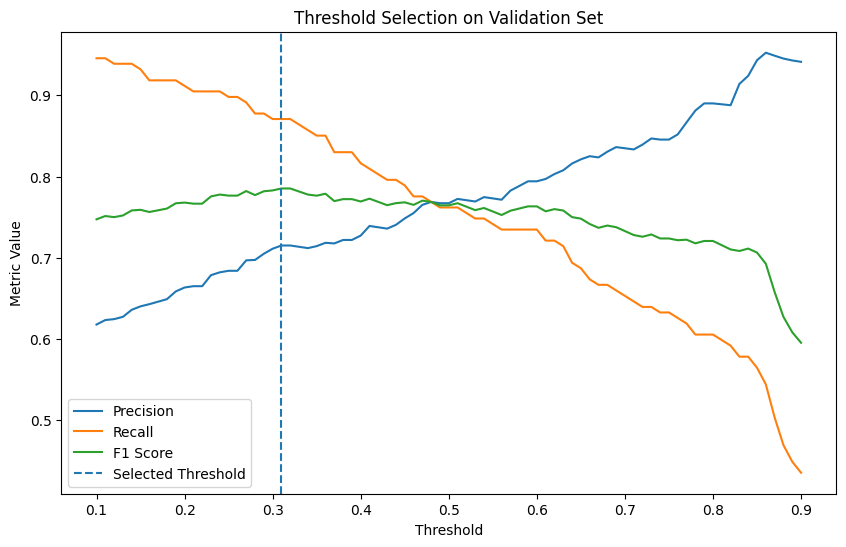

In [ ]:
# Threshold Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    threshold_df['threshold'],
    threshold_df['precision'],
    label='Precision'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['recall'],
    label='Recall'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['f1'],
    label='F1 Score'
)

plt.axvline(
    x=0.31,
    linestyle='--',
    label='Selected Threshold'
)

plt.xlabel('Threshold')
plt.ylabel('Metric Value')
plt.title('Threshold Selection on Validation Set')
plt.legend()

plt.show()

## Decision Threshold Selection

The default classification threshold for binary classifiers is 0.50. However, the default threshold is not always optimal for business objectives.

For churn prediction, the primary objective is to identify customers who are likely to churn so that retention actions can be taken.

Missing a customer who is about to churn (False Negative) can result in:

- Lost future revenue
- Reduced customer lifetime value
- Increased acquisition costs to replace lost customers

In contrast, incorrectly flagging an active customer as a churn risk (False Positive) typically results in a relatively small cost such as a promotional offer or retention campaign.

Therefore, a threshold that prioritizes recall while maintaining acceptable precision is preferred.

The threshold search was performed on the validation dataset.

The best-performing threshold was 0.31.

Validation Performance at Threshold 0.31:

- Precision: 71.5%
- Recall: 87.1%
- F1 Score: 78.5%

This threshold achieved the highest F1 score while maintaining a recall greater than 85%.

Therefore, a threshold of 0.31 was selected for the final model because it successfully balances:

- High recall (capturing most potential churners)
- Reasonable precision (limiting unnecessary retention interventions)

From a business perspective, this threshold minimizes the risk of missing customers who are likely to churn while keeping retention campaign costs manageable.

## Final test evaluation and model saving

The final model is evaluated on the held-out test set using the selected threshold. The chosen model pipeline and metrics will be saved

In [65]:
import json
import joblib

probs_test = hgb_model.predict_proba(X_test)[:, 1]
preds_test = (probs_test >= threshold).astype(int)
metrics_test = {
    'accuracy': float(accuracy_score(y_test, preds_test)),
    'precision': float(precision_score(y_test, preds_test)),
    'recall': float(recall_score(y_test, preds_test)),
    'f1': float(f1_score(y_test, preds_test)),
    'roc_auc': float(roc_auc_score(y_test, probs_test)),
    'pr_auc': float(average_precision_score(y_test, probs_test)),
    'threshold': threshold,
    'confusion_matrix': confusion_matrix(y_test, preds_test).tolist()
}

print('Test metrics:')
for k, v in metrics_test.items():
    print(k, v)

joblib.dump(hgb_model, DATA_DIR / 'model.pkl')
with open(DATA_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_test, f, indent=2)
print('\nSaved model.pkl and metrics.json')

Test metrics:
accuracy 0.7767857142857143
precision 0.7268292682926829
recall 0.8869047619047619
f1 0.7989276139410187
roc_auc 0.8634849773242631
pr_auc 0.8438620965986042
threshold 0.31
confusion_matrix [[112, 56], [19, 149]]

Saved model.pkl and metrics.json


## 6. Feature importance and interpretability

Permutation importance on validation data identifies the features that most influence predictions.

Key driver features should be interpretable and connected to retention strategy.

In [68]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    hgb_model,
    X_valid,
    y_valid,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X_valid.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
})

importance_df = (
    importance_df
    .sort_values(
        'importance',
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df.head(15)

,feature,importance,std
0,recency_days,0.171131,0.027927
1,monetary_180d,0.039881,0.007314
2,avg_discount_pct_180d,0.005655,0.006019
3,preferred_category_Hair Care,0.005357,0.002227
4,frequency_180d,0.005060,0.004219
5,age_group_35-44,0.004464,0.002744
6,avg_resolution_hours_90d,0.004464,0.004658
7,wishlist_adds_30d,0.002976,0.004414
8,preferred_category_Wellness,0.002679,0.000893
9,acquisition_channel_Organic,0.002679,0.003633


## 7. Error analysis

We analyze false positives and false negatives on the test set. Each error type has a distinct business cost:

- **False positive**: predicted churn but customer did not churn — risk of wasted retention spend.
- **False negative**: predicted no churn but customer churned — risk of lost revenue and missed outreach.

In [ ]:
errors = pd.DataFrame({
    'customer_id': test_df['customer_id'].values,
    'actual': y_test.values,
    'predicted': preds_test,
    'probability': probs_test
})
errors = errors[errors['actual'] != errors['predicted']].copy()
errors['error_type'] = np.where((errors['actual'] == 1) & (errors['predicted'] == 0), 'FN', 'FP')

# preserve example context from test features
context_columns = ['customer_id'] + feature_columns
# For error analysis, you want the original customer information exactly as it appeared in the dataset.
context = context = test_df.copy()
errors = errors.merge(context, on='customer_id', how='left')

fp_examples = errors[errors['error_type'] == 'FP'].sort_values('probability', ascending=False).head(5)
fn_examples = errors[errors['error_type'] == 'FN'].sort_values('probability', ascending=True).head(5)

print('False Positive examples:')
display(fp_examples[['customer_id', 'probability', 'actual', 'predicted', 'recency_days', 'frequency_180d', 'monetary_180d', 'ticket_count_90d', 'sessions_30d']])
print('False Negative examples:')
display(fn_examples[['customer_id', 'probability', 'actual', 'predicted', 'recency_days', 'frequency_180d', 'monetary_180d', 'ticket_count_90d', 'sessions_30d']])

False Positive examples:


,customer_id,probability,actual,predicted,recency_days,frequency_180d,monetary_180d,ticket_count_90d,sessions_30d
39,CUST01370,0.982237,0,1,161,2,1246.04,0,2
32,CUST01246,0.972420,0,1,262,0,0.00,0,1
12,CUST00437,0.958177,0,1,151,1,729.22,0,0
50,CUST01614,0.958149,0,1,103,2,1352.11,0,4
27,CUST01017,0.948232,0,1,133,2,1167.28,0,3


False Negative examples:


,customer_id,probability,actual,predicted,recency_days,frequency_180d,monetary_180d,ticket_count_90d,sessions_30d
4,CUST00184,0.004981,1,0,14,3,2456.91,0,6
63,CUST01990,0.025168,1,0,59,4,3877.77,0,11
33,CUST01253,0.042714,1,0,99,2,2035.62,0,13
53,CUST01655,0.049477,1,0,13,2,1358.99,0,2
21,CUST00838,0.051302,1,0,9,1,402.67,1,11


## Summary

- The final model is a `HistGradientBoostingClassifier` pipeline saved as `model.pkl`.
- Final metrics are stored in `metrics.json`.
- The chosen threshold is the value selected from validation data (`threshold`), balancing F1 and business recall.
- The error analysis includes specific customer examples for business review.